SHAP EXPLAINABLE AI

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import shap

In [2]:
X_train = joblib.load(
    "../processed/X_train.pkl"
)

X_test = joblib.load(
    "../processed/X_test.pkl"
)

In [3]:
xgb = joblib.load(
    "../models/xgboost.pkl"
)

In [4]:
explainer = shap.Explainer(xgb)

In [5]:
shap_values = explainer(X_test)

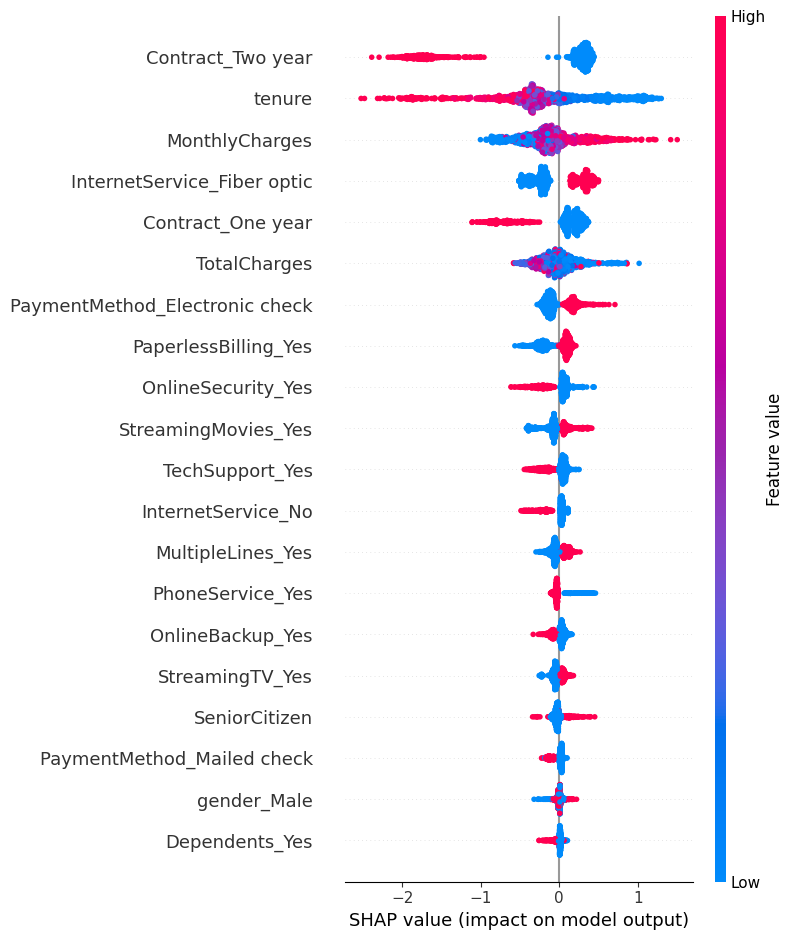

In [6]:
shap.summary_plot(
    shap_values,
    X_test
)

## Business Insights

Phân tích SHAP Summary Plot cho thấy các yếu tố ảnh hưởng mạnh nhất đến khả năng khách hàng rời bỏ dịch vụ (churn) bao gồm:

### 1. Contract_Two year
Khách hàng sử dụng hợp đồng 2 năm có xu hướng churn thấp hơn đáng kể.  
Điều này cho thấy hợp đồng dài hạn giúp tăng mức độ gắn bó của khách hàng với doanh nghiệp.

### 2. Tenure
Khách hàng có thời gian sử dụng dịch vụ ngắn thường có nguy cơ churn cao hơn.  
Ngược lại, khách hàng sử dụng lâu năm có xu hướng trung thành hơn.

### 3. MonthlyCharges
Khách hàng có chi phí hàng tháng cao dễ churn hơn.  
Điều này cho thấy giá dịch vụ có ảnh hưởng lớn đến quyết định rời bỏ.

### 4. InternetService_Fiber optic
Người dùng dịch vụ Fiber Optic có tỷ lệ churn cao hơn so với các loại dịch vụ internet khác.  
Nguyên nhân có thể liên quan đến giá cao hoặc kỳ vọng chất lượng dịch vụ.

### 5. Contract_One year
Hợp đồng 1 năm cũng giúp giảm churn nhưng mức ảnh hưởng thấp hơn hợp đồng 2 năm.

### 6. PaymentMethod_Electronic check
Khách hàng thanh toán bằng Electronic Check có xu hướng churn cao hơn.  
Điều này có thể phản ánh nhóm khách hàng ít gắn bó hoặc có trải nghiệm thanh toán chưa tối ưu.

### 7. OnlineSecurity_Yes và TechSupport_Yes
Khách hàng sử dụng các dịch vụ bổ sung như Online Security và Tech Support có xu hướng churn thấp hơn.  
Điều này cho thấy các dịch vụ giá trị gia tăng giúp cải thiện mức độ hài lòng.

### 8. SeniorCitizen
Khách hàng thuộc nhóm Senior Citizen có nguy cơ churn cao hơn một chút so với nhóm còn lại.

---

## Business Recommendations

- Khuyến khích khách hàng đăng ký hợp đồng dài hạn thông qua ưu đãi hoặc giảm giá.
- Tập trung giữ chân khách hàng mới trong những tháng đầu sử dụng dịch vụ.
- Xem xét tối ưu mức phí hàng tháng hoặc tạo các gói dịch vụ linh hoạt hơn.
- Cải thiện trải nghiệm của khách hàng sử dụng Fiber Optic.
- Đẩy mạnh các dịch vụ bổ sung như Tech Support và Online Security.
- Theo dõi nhóm khách hàng có MonthlyCharges cao để triển khai chiến dịch retention phù hợp.

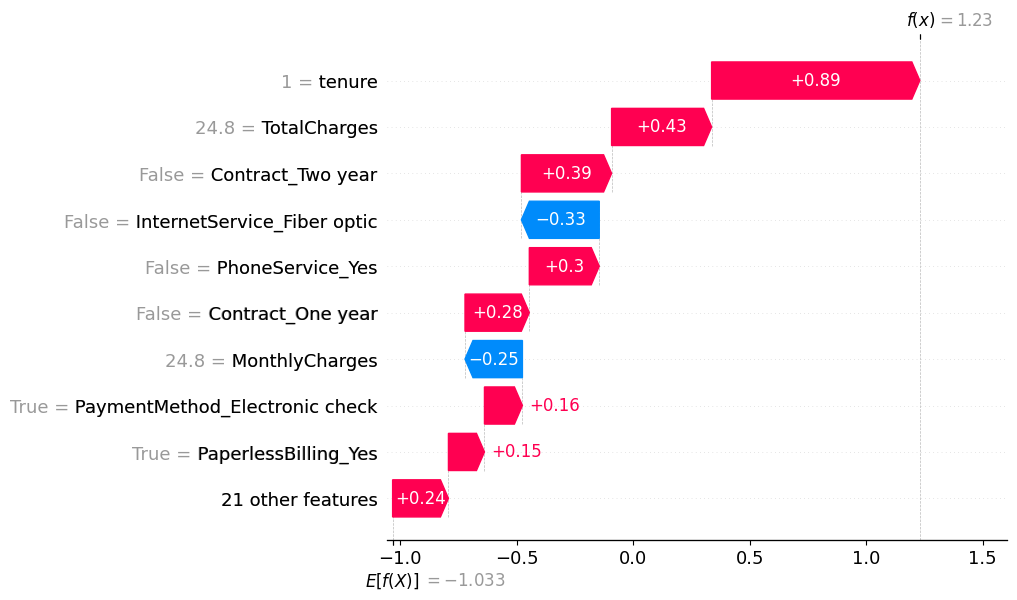

In [8]:
shap.plots.waterfall(
    shap_values[0]
)

## Customer-Level Business Insights

Phân tích SHAP Waterfall Plot cho thấy khách hàng này có xác suất churn khá cao do nhiều yếu tố tiêu cực cùng tác động.

### Các yếu tố làm tăng khả năng churn

#### 1. Tenure rất thấp
Đây là yếu tố ảnh hưởng mạnh nhất làm tăng churn probability.

Khách hàng mới sử dụng dịch vụ trong thời gian ngắn thường chưa có mức độ gắn bó cao với doanh nghiệp và dễ chuyển sang đối thủ cạnh tranh.

---

#### 2. Không sử dụng hợp đồng dài hạn
Khách hàng không đăng ký:

- Contract_One year
- Contract_Two year

Điều này cho thấy khách hàng đang sử dụng hình thức hợp đồng ngắn hạn hoặc theo tháng, dẫn đến khả năng rời bỏ dịch vụ cao hơn.

---

#### 3. Sử dụng Electronic Check
Khách hàng thanh toán bằng Electronic Check có xu hướng churn cao hơn theo mô hình.

Điều này có thể phản ánh mức độ cam kết thấp hoặc trải nghiệm thanh toán chưa tối ưu.

---

#### 4. Paperless Billing
Khách hàng sử dụng hóa đơn điện tử cũng góp phần làm tăng churn probability nhẹ.

---

### Các yếu tố giúp giảm churn

#### 1. MonthlyCharges thấp
Chi phí hàng tháng thấp giúp giảm phần nào khả năng churn.

---

#### 2. Không sử dụng Fiber Optic
Khách hàng không sử dụng Fiber Optic giúp giảm churn risk nhẹ theo mô hình.

---

## Tổng kết

Mặc dù có một vài yếu tố tích cực, nhưng:

- thời gian sử dụng dịch vụ ngắn
- không có hợp đồng dài hạn
- phương thức thanh toán Electronic Check

là những nguyên nhân chính khiến mô hình dự đoán khách hàng này có nguy cơ churn cao.

---

## Business Recommendations

- Triển khai chương trình giữ chân khách hàng mới trong 3–6 tháng đầu.
- Khuyến khích chuyển sang hợp đồng dài hạn thông qua ưu đãi hoặc giảm giá.
- Theo dõi nhóm khách hàng thanh toán bằng Electronic Check để thực hiện retention campaigns.
- Tăng mức độ tương tác và chăm sóc cá nhân hóa với khách hàng mới.

In [9]:
shap.initjs()

shap.force_plot(
    explainer.expected_value,
    shap_values.values[0],
    X_test.iloc[0]
)